Fetching data from GitHub: https://raw.githubusercontent.com/Vrishketan/ITA-Project/main/sample_data/energy_consumption_1000_households.csv
Dataset Loaded Successfully


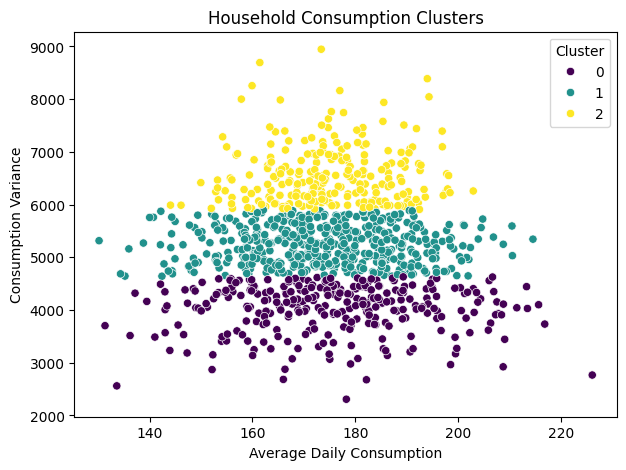

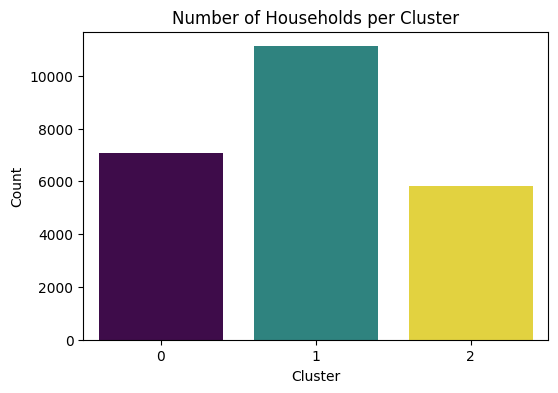


Global Random Forest
RMSE: 79.1136
MAE : 66.7215
R2  : -0.1922

Global Gradient Boosting
RMSE: 71.5138
MAE : 61.6513
R2  : 0.0259


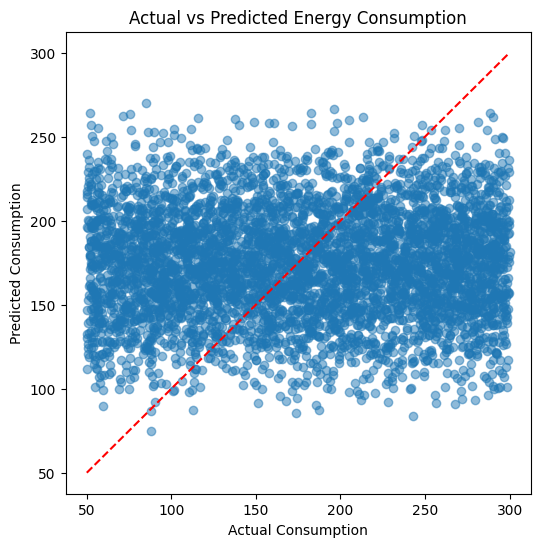


--- Cluster 0 ---

Cluster Random Forest
RMSE: 70.4948
MAE : 59.193
R2  : -0.1794

Cluster Gradient Boosting
RMSE: 63.794
MAE : 54.084
R2  : 0.0342

--- Cluster 1 ---

Cluster Random Forest
RMSE: 80.1712
MAE : 68.4143
R2  : -0.2085

Cluster Gradient Boosting
RMSE: 72.3163
MAE : 62.6533
R2  : 0.0167

--- Cluster 2 ---

Cluster Random Forest
RMSE: 86.9451
MAE : 74.2755
R2  : -0.1793

Cluster Gradient Boosting
RMSE: 80.1786
MAE : 71.269
R2  : -0.0029


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import requests
import io

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f'\n{name}')
    print(f'RMSE: {round(rmse, 4)}')
    print(f'MAE : {round(mae, 4)}')
    print(f'R2  : {round(r2, 4)}')

def run_analysis(url):

    print(f"Fetching data from GitHub: {url}")
    response = requests.get(url)

    if response.status_code != 200:
        print("Error: Could not retrieve file from GitHub.")
        return

    df = pd.read_csv(io.StringIO(response.text))
    print("Dataset Loaded Successfully")

    # Feature engineering
    df['Peak_Hour_Flag'] = df['Hour'].apply(lambda x: 1 if x in [6,7,8,18,19,20] else 0)

    df['Daily_Avg_kWh'] = df.groupby('Household_ID')['Energy_Consumption_kWh'].transform('mean')

    df['Daily_Variance'] = df.groupby('Household_ID')['Energy_Consumption_kWh'].transform('var').fillna(0)

    # ---------------- CLUSTERING ----------------

    household_features = df.groupby('Household_ID').agg({
        'Daily_Avg_kWh':'mean',
        'Daily_Variance':'mean'
    }).reset_index()

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

    household_features['Cluster'] = kmeans.fit_predict(
        household_features[['Daily_Avg_kWh','Daily_Variance']]
    )

    df = df.merge(
        household_features[['Household_ID','Cluster']],
        on='Household_ID',
        how='left'
    )

    # -------- VISUAL 1 : CLUSTER SCATTER --------

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=household_features,
        x='Daily_Avg_kWh',
        y='Daily_Variance',
        hue='Cluster',
        palette='viridis'
    )

    plt.title("Household Consumption Clusters")
    plt.xlabel("Average Daily Consumption")
    plt.ylabel("Consumption Variance")
    plt.show()

    # -------- VISUAL 2 : CLUSTER SIZE --------

    plt.figure(figsize=(6,4))
    sns.countplot(x='Cluster', hue='Cluster', data=df, palette='viridis', legend=False)

    plt.title("Number of Households per Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.show()

    # ---------------- GLOBAL MODELS ----------------

    features = ['Hour','Peak_Hour_Flag','Daily_Avg_kWh','Daily_Variance']
    target = 'Energy_Consumption_kWh'

    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,y,test_size=0.2,random_state=42
    )

    rf = RandomForestRegressor(random_state=42).fit(X_train,y_train)
    gb = GradientBoostingRegressor(random_state=42).fit(X_train,y_train)

    rf_pred = rf.predict(X_test)

    evaluate(y_test, rf_pred, "Global Random Forest")
    evaluate(y_test, gb.predict(X_test), "Global Gradient Boosting")

    # -------- VISUAL 3 : ACTUAL VS PREDICTED --------

    plt.figure(figsize=(6,6))

    plt.scatter(y_test, rf_pred, alpha=0.5)

    plt.xlabel("Actual Consumption")
    plt.ylabel("Predicted Consumption")

    plt.title("Actual vs Predicted Energy Consumption")

    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')

    plt.show()

    # ---------------- CLUSTER MODELS ----------------

    for cluster in sorted(df['Cluster'].unique()):

        print(f'\n--- Cluster {cluster} ---')

        c_df = df[df['Cluster']==cluster]

        Xc = c_df[features]
        yc = c_df[target]

        Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
            Xc,yc,test_size=0.2,random_state=42
        )

        # Random Forest
        rf_model = RandomForestRegressor(random_state=42).fit(Xc_tr,yc_tr)
        evaluate(yc_te, rf_model.predict(Xc_te), "Cluster Random Forest")

        # Gradient Boosting
        gb_model = GradientBoostingRegressor(random_state=42).fit(Xc_tr,yc_tr)
        evaluate(yc_te, gb_model.predict(Xc_te), "Cluster Gradient Boosting")


if __name__ == '__main__':

    url = 'https://raw.githubusercontent.com/Vrishketan/ITA-Project/main/sample_data/energy_consumption_1000_households.csv'

    run_analysis(url)